# 6CS012 - Artificial Intelligence and Machine Learning
## Building Fully Connected Neural Networks for Devnagari Handwritten Digit Classification

## Worksheet - 4
## Name: Atul Adhikari
## Student Number: 2408982

### Installing Keras

In [2]:
pip install keras tensorflow

### Identifying the version of Keras

In [3]:
import tensorflow as tf
print(tf.keras.__version__)

3.13.2


###Manual Gradient Calculation in Numpy

In [4]:
# Manual Gradient Calculation in Numpy
import numpy as np

# Simple function f(x) = x^2
def f(x):
    return x ** 2

# Manual derivative (f'(x) = 2x)
def gradient(x):
    return 2 * x

# Update rule: x = x - learning_rate * gradient
x = 5.0
learning_rate = 0.1
for _ in range(10):  # Manually optimize for 10 steps
    x -= learning_rate * gradient(x)
    print(f"x: {x}, f(x): {f(x)}")

x: 4.0, f(x): 16.0
x: 3.2, f(x): 10.240000000000002
x: 2.56, f(x): 6.5536
x: 2.048, f(x): 4.194304
x: 1.6384, f(x): 2.68435456
x: 1.31072, f(x): 1.7179869184000003
x: 1.0485760000000002, f(x): 1.0995116277760004
x: 0.8388608000000002, f(x): 0.7036874417766403
x: 0.6710886400000001, f(x): 0.45035996273704976
x: 0.5368709120000001, f(x): 0.2882303761517119


In [5]:
# Gradient Computations with Keras
import tensorflow as tf

x = tf.Variable(5.0)  # Trainable variable
with tf.GradientTape() as tape:
    y = x ** 2  # y = x^2

grad = tape.gradient(y, x)  # Computes dy/dx automatically
print(grad.numpy())  # Output: 10.0

10.0


###Matrix Multiplication Speed (Numpy vs. Tensorflow on GPU)

In [6]:
# Example: Matrix Multiplication Speed (Numpy vs. Tensorflow on GPU)
import numpy as np
import tensorflow as tf
import time

# Create large random matrices
size = (1000, 1000)
A = np.random.rand(*size)
B = np.random.rand(*size)

# NumPy Multiplication
start = time.time()
C_numpy = np.dot(A, B)
print("NumPy Time:", time.time() - start)

# TensorFlow Multiplication (for colab uses GPU Runtime if available)
A_tf = tf.constant(A)
B_tf = tf.constant(B)
start = time.time()
C_tf = tf.matmul(A_tf, B_tf)
print("TensorFlow Time:", time.time() - start)

NumPy Time: 0.06621456146240234
TensorFlow Time: 0.15567255020141602


In [7]:
# Implementation of Activation Function with Keras
from tensorflow.keras.layers import Dense

layer = Dense(64, activation='sigmoid')

In [8]:
# Manually Training Network in Numpy (illustrative example)
import numpy as np

# Dummy data for illustration
np.random.seed(42)
x_train_np = np.random.randn(100, 3)
y_train_np = np.random.randn(100, 1)
weights = np.random.randn(3, 1)
learning_rate = 0.01

for epoch in range(10):
    # Forward pass
    y_pred = np.dot(x_train_np, weights)
    # Compute loss
    loss = np.mean((y_pred - y_train_np) ** 2)
    # Compute gradients manually
    gradients = 2 * np.dot(x_train_np.T, (y_pred - y_train_np)) / len(x_train_np)
    # Update weights
    weights -= learning_rate * gradients

print("Final loss:", loss)

Final loss: 2.1816702076704337


###keras training is One Line.

In [9]:
#model.fit(x_train, y_train, epochs=10, batch_size=32)

In [10]:
# Layers in Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(64, activation='relu', input_shape=(784,)),
    Dense(10, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
# Implementing SGD in Numpy
learning_rate = 0.01
weights = np.random.randn(3, 3)

for _ in range(100):  # Training loop
    gradient = np.random.randn(3, 3)  # Fake gradient for illustration
    weights -= learning_rate * gradient

In [12]:
# In Keras
from tensorflow.keras.optimizers import SGD

optimizer = SGD(learning_rate=0.01)

In [13]:
# Syntax of Dense Layer
from tensorflow.keras.layers import Dense
# layer = Dense(units, activation=None, use_bias=True, kernel_initializer="glorot_uniform")

In [14]:
# Example: A Dense Layer with 64 Neurons and sigmoid Activation
from tensorflow.keras.layers import Dense

layer = Dense(64, activation="sigmoid")  # 64 neurons with sigmoid activation

##  Building a Simple Fully Connected Neural Network in Keras

Training set: (17000, 28, 28, 1), Labels: (17000, 10)
Testing set: (3000, 28, 28, 1), Labels: (3000, 10)


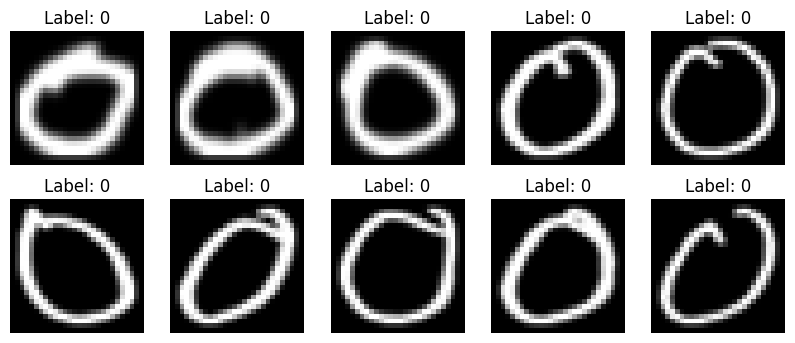

In [17]:
# Loading and Preprocessing Data with PIL
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image  # Import Pillow

# Define dataset paths
train_dir = "/content/drive/MyDrive/Artificial Intelligence and Machine Learning /Worksheet4 Dataset/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/drive/MyDrive/Artificial Intelligence and Machine Learning /Worksheet4 Dataset/DevanagariHandwrittenDigitDataset/Test"

# Define image size
img_height, img_width = 28, 28

# Function to load images and labels using PIL
def load_images_from_folder(folder):
    images = []
    labels = []
    class_names = sorted(os.listdir(folder))  # Sorted class names (digit_0, digit_1, ...)
    class_map = {name: i for i, name in enumerate(class_names)}  # Map class names to labels

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            # Load image using PIL
            img = Image.open(img_path).convert("L")  # Convert to grayscale
            img = img.resize((img_width, img_height))  # Resize to (28,28)
            img = np.array(img) / 255.0  # Normalize pixel values to [0,1]
            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)

# Load training and testing datasets
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

# Reshape images for Keras input
x_train = x_train.reshape(-1, img_height, img_width, 1)  # Shape (num_samples, 28, 28, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Print dataset shape
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")

# Visualize some images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis("off")
plt.show()

In [18]:
# Compatibility check for Grayscale Image
x_train = x_train.reshape(-1, img_height, img_width, 1)

# Compatibility check for RGB Image (This line caused the error and should be removed if data is grayscale)
# x_train = x_train.reshape(-1, img_height, img_width, 3)

In [19]:
# Loading and Preprocessing
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

# Normalize the images to values between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0

# Flatten the 28x28 images into 784-dimensional vectors
x_train = x_train.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28 * 28)

# One-hot encode the labels for classification
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

In [20]:
# Example using Sequential API
import tensorflow as tf
from tensorflow import keras

# Model parameters
num_classes = 10
input_shape = (28, 28, 1)

model = keras.Sequential(
    [
        keras.layers.Input(shape=input_shape),
        keras.layers.Flatten(),  # Flatten the 28x28 image to a 784-dimensional vector
        keras.layers.Dense(64, activation="sigmoid"),
        keras.layers.Dense(128, activation="sigmoid"),
        keras.layers.Dense(256, activation="sigmoid"),
        keras.layers.Dense(num_classes, activation="softmax"),
    ]
)

In [21]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# # Example using Functional API
# import tensorflow as tf
# from tensorflow import keras

# # Model parameters
# num_classes = 10
# input_shape = (28, 28, 1)

# def build_functional_model():
#     # Input layer
#     inputs = keras.Input(shape=input_shape)
#     # Flatten layer
#     x = keras.layers.Flatten()(inputs)
#     # Hidden layers
#     x = keras.layers.Dense(64, activation="sigmoid")(x)
#     x = keras.layers.Dense(128, activation="sigmoid")(x)
#     x = keras.layers.Dense(256, activation="sigmoid")(x)
#     # Output layer
#     outputs = keras.layers.Dense(num_classes, activation="softmax")(x)
#     # Create model
#     model = keras.Model(inputs=inputs, outputs=outputs)
#     return model

# # Build the model
# functional_model = build_functional_model()
# functional_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# # Syntax of model.compile()
# # model.compile(
# #     optimizer=<optimizer>,
# #     loss=<loss_function>,
# #     metrics=[<metric1>, <metric2>, ...]
# # )

# # Example: Compiling the Model
# functional_model.compile(
#     optimizer="adam",
#     loss="categorical_crossentropy",
#     metrics=["accuracy"]
# )

In [30]:
print(functional_model.input_shape)

(None, 28, 28, 1)


In [33]:
print("y_train shape:", y_train.shape)
print("Sample label:", y_train[0])
print("x_train_reshaped shape:", x_train_reshaped.shape)

y_train shape: (17000, 10)
Sample label: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
x_train_reshaped shape: (17000, 28, 28, 1)


In [34]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

# Clear any old session/model state
tf.keras.backend.clear_session()

num_classes = 10
input_shape = (28, 28, 1)

# Rebuild the model fresh
functional_model = keras.Sequential([
    keras.layers.Input(shape=input_shape),
    keras.layers.Flatten(),
    keras.layers.Dense(64,  activation="sigmoid"),
    keras.layers.Dense(128, activation="sigmoid"),
    keras.layers.Dense(256, activation="sigmoid"),
    keras.layers.Dense(num_classes, activation="softmax"),
])

functional_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

functional_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
x_train_reshaped = x_train.reshape(-1, 28, 28, 1)

history = functional_model.fit(
    x_train_reshaped,
    y_train,
    batch_size=128,
    epochs=50,
    validation_split=0.15,
    verbose=1
)

Epoch 1/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.1157 - loss: 2.1978 - val_accuracy: 0.0000e+00 - val_loss: 6.3117
Epoch 2/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1203 - loss: 2.1903 - val_accuracy: 0.0000e+00 - val_loss: 6.7523
Epoch 3/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1135 - loss: 2.1873 - val_accuracy: 0.0000e+00 - val_loss: 6.9970
Epoch 4/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1292 - loss: 2.1843 - val_accuracy: 0.0000e+00 - val_loss: 7.0792
Epoch 5/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1760 - loss: 2.1639 - val_accuracy: 0.0000e+00 - val_loss: 7.2715
Epoch 6/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2906 - loss: 1.9917 - val_accuracy: 0.0000e+00 - val_loss: 7.4090
Epoch 7/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4653 - loss: 1.5084 - val_accuracy: 0.0000e+00 - val_loss: 7.7812
Epoch 8/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5362 - los

In [36]:
# batch_size = 128
# epochs = 50

# callbacks = [
#     keras.callbacks.ModelCheckpoint(filepath="/content/drive/MyDrive/Artificial Intelligence and Machine Learning /Worksheet4 Checkpoint/model_at_epoch_{epoch}.keras"),
#     keras.callbacks.EarlyStopping(monitor="val_loss", patience=4),
# ]

# x_train_reshaped = x_train.reshape(-1, 28, 28, 1)

# history = functional_model.fit(
#     x_train_reshaped,
#     y_train,
#     batch_size=batch_size,
#     epochs=epochs,
#     validation_split=0.15,
#     callbacks=callbacks,
# )

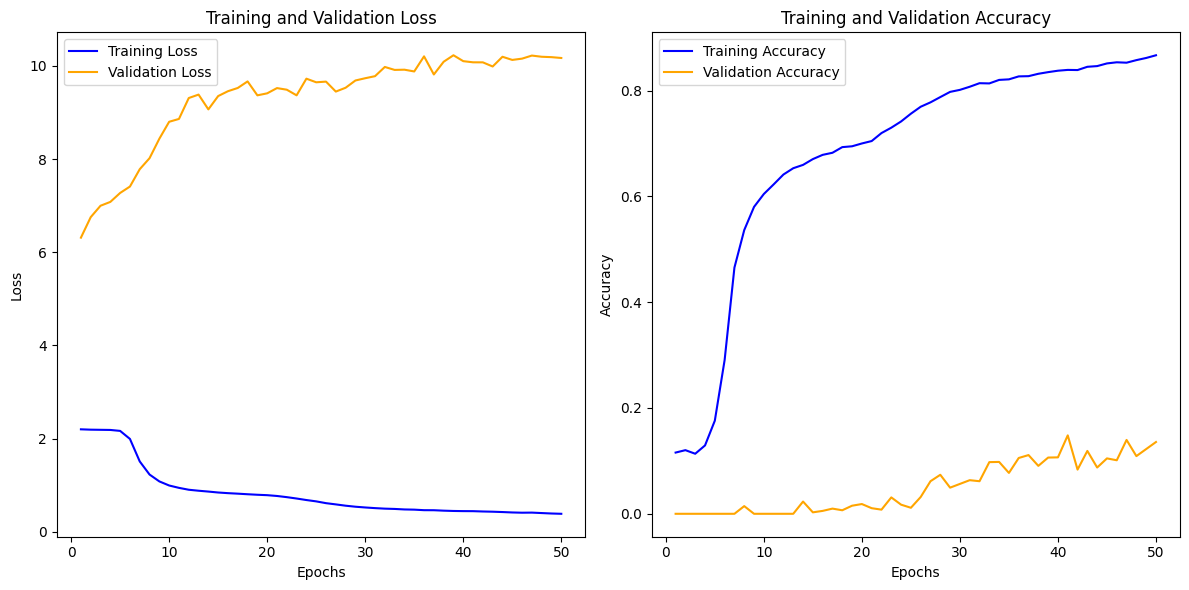

In [37]:
# Sample Code for visualizing Model's Training Progress
import matplotlib.pyplot as plt

# Assuming 'history' is the object returned by model.fit()
# Extracting training and validation loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Extracting training and validation accuracy (if metrics were specified)
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Plotting training and validation loss
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss) + 1), train_loss, label='Training Loss', color='blue')
plt.plot(range(1, len(val_loss) + 1), val_loss, label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_acc) + 1), train_acc, label='Training Accuracy', color='blue')
plt.plot(range(1, len(val_acc) + 1), val_acc, label='Validation Accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [43]:
# Example code for Evaluation
# Reshape x_test to match the functional_model's expected input shape (28, 28, 1)
x_test_reshaped = x_test.reshape(-1, img_height, img_width, 1)
test_loss, test_acc = functional_model.evaluate(x_test_reshaped, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")

94/94 - 0s - 2ms/step - accuracy: 0.7520 - loss: 1.8676
Test accuracy: 0.7520


In [46]:
# Example code for model.predict()

# Reshape x_test to match the functional_model's expected input shape (28, 28, 1)
x_test_reshaped = x_test.reshape(-1, img_height, img_width, 1)

# Predict on test data
predictions = functional_model.predict(x_test_reshaped)

# Convert predictions from probabilities to digit labels
predicted_labels = np.argmax(predictions, axis=1)

# Check the first prediction
print(f"Predicted label for first image: {predicted_labels[0]}")
print(f"True label for first image: {np.argmax(y_test[0])}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted label for first image: 0
True label for first image: 0


In [47]:
# Saving the Model
model.save('/content/drive/MyDrive/Artificial Intelligence and Machine Learning /Worksheet4 Output/model.h5')

In [48]:
# Loading the Model
loaded_model = tf.keras.models.load_model('/content/drive/MyDrive/Artificial Intelligence and Machine Learning /Worksheet4 Output/model.h5')

Training samples : (17000, 784)  |  Labels: (17000, 10)
Testing  samples : (3000, 784)   |  Labels: (3000, 10)


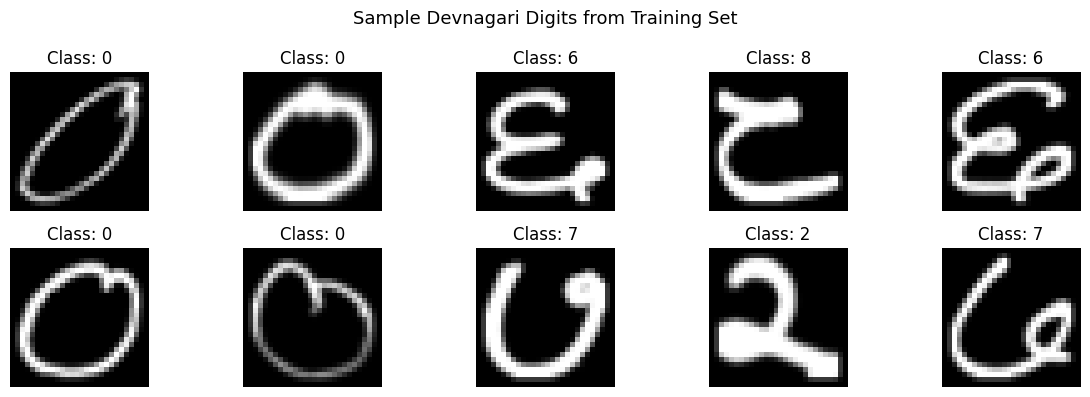

In [85]:
# Task 1: Data Preparation
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from PIL import Image

train_dir = "/content/drive/MyDrive/Artificial Intelligence and Machine Learning /Worksheet4 Dataset/DevanagariHandwrittenDigitDataset/Train"
test_dir  = "/content/drive/MyDrive/Artificial Intelligence and Machine Learning /Worksheet4 Dataset/DevanagariHandwrittenDigitDataset/Test"

IMG_H, IMG_W = 28, 28   # resize every image to 28x28
NUM_CLASSES  = 10

def load_dataset(folder):
    """
    Walk through every class sub-folder, open each image with PIL,
    resize + normalise it, and collect image arrays alongside integer labels.
    Returns (images, one-hot-labels) as numpy arrays.
    """
    images, labels = [], []

    # Sort so the mapping is always deterministic: digit_0 → 0, digit_1 → 1 …
    class_names = sorted(os.listdir(folder))
    class_map   = {name: idx for idx, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        if not os.path.isdir(class_path):   # skip stray files
            continue
        label = class_map[class_name]

        for fname in os.listdir(class_path):
            img_path = os.path.join(class_path, fname)
            try:
                img = Image.open(img_path).convert("L")          # grayscale
                img = img.resize((IMG_W, IMG_H))                 # 28 × 28
                img = np.array(img, dtype=np.float32) / 255.0   # normalise
                images.append(img)
                labels.append(label)
            except Exception as e:
                print(f"Skipping {img_path}: {e}")

    images = np.array(images)  # (N, 28, 28)
    labels = np.array(labels)  # (N,)

    # One-hot encode the integer labels → shape (N, 10)
    labels_ohe = to_categorical(labels, num_classes=NUM_CLASSES)

    return images, labels_ohe


# Load both splits
x_train, y_train = load_dataset(train_dir)
x_test,  y_test  = load_dataset(test_dir)


indices = np.random.permutation(len(x_train))
x_train = x_train[indices]
y_train = y_train[indices]

# Flatten 28x28 → 784-dim vectors (required by a fully-connected network)
x_train_flat = x_train.reshape(-1, IMG_H * IMG_W)
x_test_flat  = x_test.reshape(-1,  IMG_H * IMG_W)

print(f"Training samples : {x_train_flat.shape}  |  Labels: {y_train.shape}")
print(f"Testing  samples : {x_test_flat.shape}   |  Labels: {y_test.shape}")

# Quick sanity-check – show the first 10 training images
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Class: {np.argmax(y_train[i])}")
    plt.axis("off")
plt.suptitle("Sample Devnagari Digits from Training Set", fontsize=13)
plt.tight_layout()
plt.show()

In [65]:
# Task 2: Build the FCN Model
fcn_model = keras.Sequential(
    [
        # Input + flatten are already done above, so we accept a 784-dim vector directly
        keras.layers.Input(shape=(IMG_H * IMG_W,)),

        # Hidden layer 1
        keras.layers.Dense(64, activation="sigmoid"),

        # Hidden layer 2
        keras.layers.Dense(128, activation="sigmoid"),

        # Hidden layer 3
        keras.layers.Dense(256, activation="sigmoid"),

        # Output layer – 10 classes, softmax for probability distribution
        keras.layers.Dense(NUM_CLASSES, activation="softmax"),
    ],
    name="Devnagari_FCN"
)

fcn_model.summary()

Model: "Devnagari_FCN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [71]:
# Task 3: Compile the Model
# y_train is already one-hot encoded, so we use categorical_crossentropy.
# Adam is a solid default optimizer that adapts the learning rate automatically.
fcn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [78]:
print("x_train shape     :", x_train.shape)
print("x_train_flat shape:", x_train_flat.shape)
print("y_train shape     :", y_train.shape)
print("First 10 labels   :", np.argmax(y_train[:10], axis=1))

x_train shape     : (17000, 28, 28)
x_train_flat shape: (17000, 784)
y_train shape     : (17000, 10)
First 10 labels   : [4 5 6 5 9 7 9 1 7 8]


In [87]:
tf.keras.backend.clear_session()

fcn_model = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(64,  activation="relu"),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(256, activation="relu"),
    keras.layers.Dense(10,  activation="softmax"),
], name="Devnagari_FCN")

fcn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = fcn_model.fit(
    x_train_flat,
    y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8324 - loss: 0.5612 - val_accuracy: 0.9324 - val_loss: 0.2165
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9526 - loss: 0.1551 - val_accuracy: 0.9635 - val_loss: 0.1292
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9735 - loss: 0.0900 - val_accuracy: 0.9691 - val_loss: 0.1028
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9812 - loss: 0.0661 - val_accuracy: 0.9697 - val_loss: 0.0957
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9849 - loss: 0.0485 - val_accuracy: 0.9735 - val_loss: 0.0864
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9874 - loss: 0.0390 - val_accuracy: 0.9753 - val_loss: 0.0856
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9910 - loss: 0.0306 - val_accuracy: 0.9776 - val_loss: 0.0787
Epoch 8/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9951 - loss: 0.0176 - val_accuracy: 0.

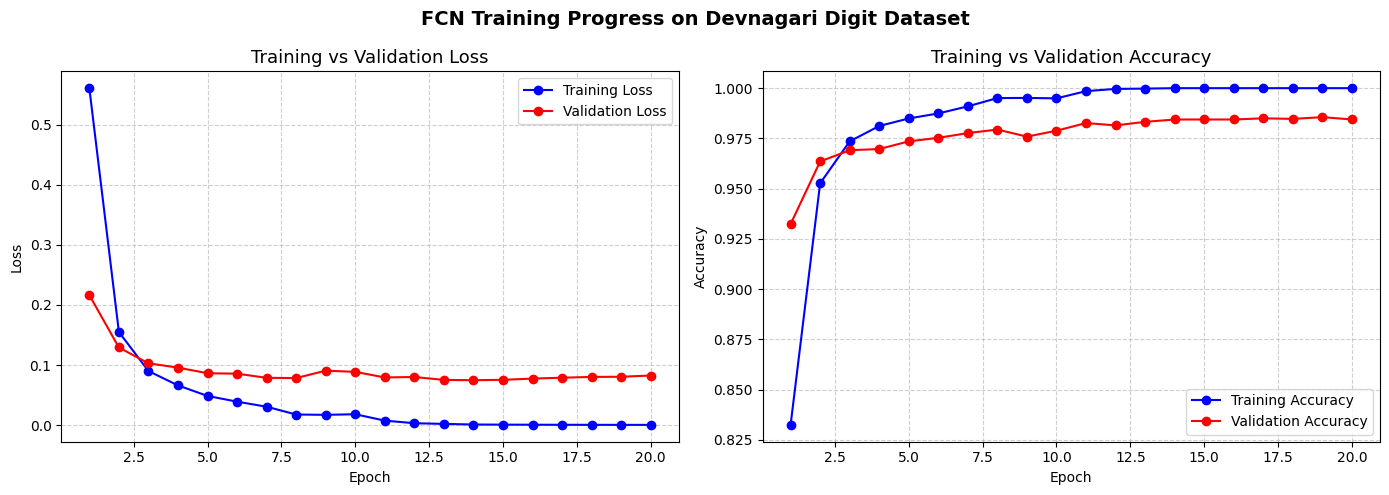

In [88]:
# Plot training history
train_loss = history.history["loss"]
val_loss   = history.history["val_loss"]
train_acc  = history.history["accuracy"]
val_acc    = history.history["val_accuracy"]
epochs_ran = range(1, len(train_loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(epochs_ran, train_loss, "b-o", label="Training Loss")
axes[0].plot(epochs_ran, val_loss,   "r-o", label="Validation Loss")
axes[0].set_title("Training vs Validation Loss",  fontsize=13)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.6)

# Accuracy curve
axes[1].plot(epochs_ran, train_acc, "b-o", label="Training Accuracy")
axes[1].plot(epochs_ran, val_acc,   "r-o", label="Validation Accuracy")
axes[1].set_title("Training vs Validation Accuracy", fontsize=13)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.suptitle("FCN Training Progress on Devnagari Digit Dataset", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [89]:
# Task 5: Evaluate the Model
test_loss, test_acc = fcn_model.evaluate(x_test_flat, y_test, verbose=2)

print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc * 100:.2f}%")

94/94 - 0s - 3ms/step - accuracy: 0.9810 - loss: 0.0884
  Test Loss     : 0.0884
  Test Accuracy : 98.10%


In [91]:
#  Task 6: Save and Load the Model

save_path = "devnagari_fcn_model.h5"
fcn_model.save(save_path)
print(f"Model saved to → {save_path}")

# --- Load ---
loaded_model = tf.keras.models.load_model(save_path)
print("Model loaded successfully.")

# --- Re-evaluate with the loaded model ---
loaded_loss, loaded_acc = loaded_model.evaluate(x_test_flat, y_test, verbose=2)

print("  Evaluation results using the LOADED model:")
print(f"  Loss     : {loaded_loss:.4f}")
print(f"  Accuracy : {loaded_acc * 100:.2f}%")

Model saved to → devnagari_fcn_model.h5
Model loaded successfully.
94/94 - 1s - 10ms/step - accuracy: 0.9810 - loss: 0.0884
  Evaluation results using the LOADED model:
  Loss     : 0.0884
  Accuracy : 98.10%


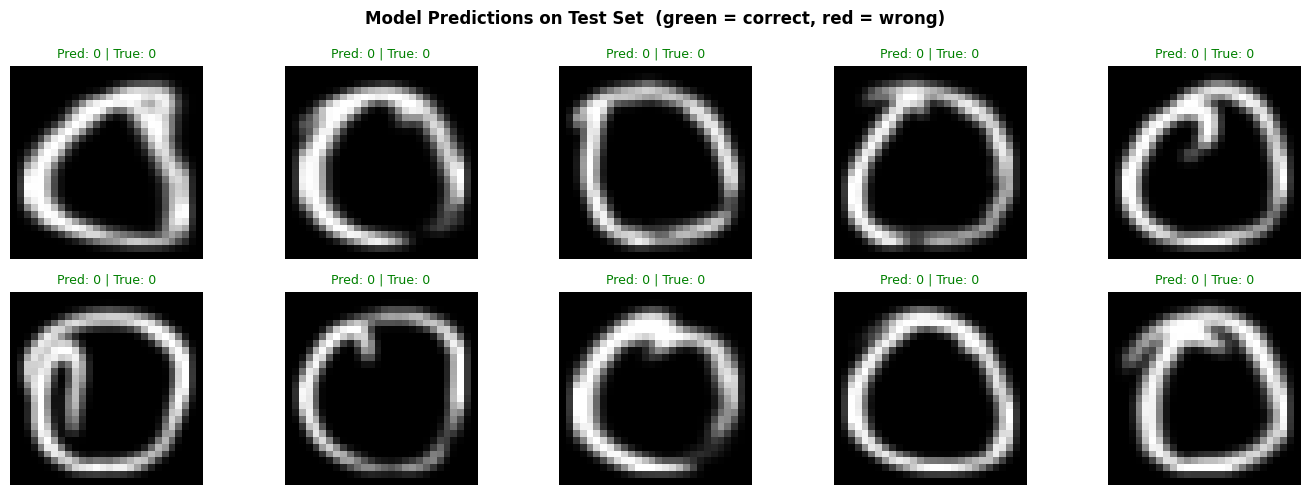


Correct predictions: 2943 / 3000  (98.10%)


In [92]:
# Task 7: Predictions

# Run predictions on the entire test set
predictions     = fcn_model.predict(x_test_flat, verbose=0)
predicted_labels = np.argmax(predictions, axis=1)   # class with highest prob
true_labels      = np.argmax(y_test, axis=1)         # decode from one-hot

# Show predictions for the first 10 test images in a grid
plt.figure(figsize=(14, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i], cmap="gray")

    pred  = predicted_labels[i]
    truth = true_labels[i]
    color = "green" if pred == truth else "red"

    plt.title(f"Pred: {pred} | True: {truth}", color=color, fontsize=9)
    plt.axis("off")

plt.suptitle(
    "Model Predictions on Test Set  (green = correct, red = wrong)",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()

# Summarise overall prediction accuracy
correct = np.sum(predicted_labels == true_labels)
total   = len(true_labels)
print(f"\nCorrect predictions: {correct} / {total}  ({100 * correct / total:.2f}%)")

In [93]:
# Detailed look at a single prediction
idx = 0   # change this to inspect a different sample

probs = predictions[idx]
print(f"Sample index        : {idx}")
print(f"True label          : {true_labels[idx]}")
print(f"Predicted label     : {predicted_labels[idx]}")
print(f"Prediction correct  : {predicted_labels[idx] == true_labels[idx]}")
print()
print("Class probabilities:")
for cls, prob in enumerate(probs):
    bar = "|" * int(prob * 40)
    print(f"  Class {cls}: {prob:.4f}  {bar}")

Sample index        : 0
True label          : 0
Predicted label     : 0
Prediction correct  : True

Class probabilities:
  Class 0: 1.0000  |||||||||||||||||||||||||||||||||||||||
  Class 1: 0.0000  
  Class 2: 0.0000  
  Class 3: 0.0000  
  Class 4: 0.0000  
  Class 5: 0.0000  
  Class 6: 0.0000  
  Class 7: 0.0000  
  Class 8: 0.0000  
  Class 9: 0.0000  
